# Double Cascade Events — Variable Study

Study of the 2 events selected as double cascade in the FinalTopology:

| Run    | Event ID  |
|--------|-----------|
| 136768 | 63259630  |
| 130730 | 58184986  |

For each variable, the astro-weighted FTP MC distribution is shown per neutrino flavour  
(NuE, NuMu, NuTau), with vertical lines marking the two data event values.

In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load datasets

In [58]:
_BDT_BASE = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/'
    'combined_with_bdt/'
)
_BDT_FEAT = 'mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/'

PATH_DATA = _BDT_BASE + 'data_HESE_pass2_v3/' + _BDT_FEAT + 'dataset_data_HESE_pass2_v3.parquet'

PATH_MC = (
    _BDT_BASE
    + 'IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight/'
    + _BDT_FEAT
    + 'dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight.parquet'
)

SAVE_PATH = (
    '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/'
    'step2_hese_flavor/study_double_cascade_events'
)
os.makedirs(SAVE_PATH, exist_ok=True)

df_data = pd.read_parquet(PATH_DATA)
df_data['run'] = df_data.index.get_level_values(0)

df_mc = pd.read_parquet(PATH_MC)

print(f'Data : {len(df_data):,} events, {len(df_data.columns)} columns')
print(f'MC   : {len(df_mc):,} events, {len(df_mc.columns)} columns')
print(f'bdt_scores1 in data: {"bdt_scores1" in df_data.columns}')
print(f'bdt_scores1 in MC  : {"bdt_scores1" in df_mc.columns}')
print(f'Save path: {SAVE_PATH}')

Data : 188 events, 76 columns
MC   : 698,848 events, 113 columns
bdt_scores1 in data: True
bdt_scores1 in MC  : True
Save path: /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/study_double_cascade_events


## 2. Astrophysical event weights

Same flux model as in `spice_vs_ftp_comparison.ipynb`.

In [59]:
PER_FLAVOR_NORM = 2.12   # 1e-18 GeV^-1 cm^-2 s^-1 sr^-1 at 100 TeV
GAMMA_ASTRO     = 2.87

def AstroFluxModel(energy):
    """Per-flavour astrophysical flux [GeV^-1 cm^-2 s^-1 sr^-1]."""
    return 0.5 * (PER_FLAVOR_NORM * 1e-18) * (energy / 1e5) ** -GAMMA_ASTRO

def get_astro_weight(df):
    energy = df['MCPrimaryEnergy'].values
    if 'fluxless_weight' in df.columns:
        fw = df['fluxless_weight'].values
    else:
        fw = df['powerlaw'].values * 1e18 * (energy / 1e5) ** 2
    return fw * AstroFluxModel(energy)

df_mc['astro_weight'] = get_astro_weight(df_mc)

FLAVORS = {
    r'$\nu_e$':    12,
    r'$\nu_\mu$':  14,
    r'$\nu_\tau$': 16,
}
FLAVOR_COLORS = {
    r'$\nu_e$':    'tab:blue',
    r'$\nu_\mu$':  'tab:orange',
    r'$\nu_\tau$': 'tab:green',
}

print('MC astro-weighted event counts by flavour:')
for label, pdg in FLAVORS.items():
    w = df_mc.loc[df_mc['MCPrimaryType'].abs() == pdg, 'astro_weight'].sum()
    print(f'  {label}: {w:.4f} events/yr')

MC astro-weighted event counts by flavour:
  $\nu_e$: 0.0000 events/yr
  $\nu_\mu$: 0.0000 events/yr
  $\nu_\tau$: 0.0000 events/yr


## 3. Extract target data event values

In [60]:
TARGET_EVENTS    = [(126283,47286594), (136768, 63259630), (130730, 58184986)]
EVENT_LABELS     = ["double double",'136768 / 63259630', '130730 / 58184986']
EVENT_LINESTYLES = ['solid','dotted','dashed']

def get_event_value(run, evt_id, variable):
    mask = (df_data['run'] == run) & (df_data['event_id'] == evt_id)
    rows = df_data[mask]
    if rows.empty or variable not in rows.columns:
        return float('nan')
    return float(rows[variable].iloc[0])

# Sanity check
check_vars = ['bdt_scores1', 'bdt_scores2', 'TauMonoDiff_rlogl',
              'Taupede_Distance', 'econfinement']
print(f"{'Variable':42s}  {'double double':>18s}  {'136768/63259630':>18s}  {'130730/58184986':>18s}")
print('-' * 84)
for v in check_vars:
    vals = [get_event_value(r, e, v) for r, e in TARGET_EVENTS]
    print(f"{v:42s} {vals[0]:18.4f} {vals[1]:18.4f} {vals[2]:18.4f}")

Variable                                         double double     136768/63259630     130730/58184986
------------------------------------------------------------------------------------
bdt_scores1                                            0.9971             0.0749             0.0369
bdt_scores2                                            0.9912             0.6835             0.3270
TauMonoDiff_rlogl                                     -0.1389            -0.0119            -0.0064
Taupede_Distance                                      17.9311            11.4617            10.3396
econfinement                                           1.0000             1.0000             0.9970


## 4. Variable definitions

Each entry: `(variable_name, xlabel, bins, log_x, log_y)`  
Adjust `bins` to zoom in or change resolution; flip `log_y` to toggle log scale on the y-axis.

In [61]:
# (variable_name, xlabel, bins, log_x, log_y)
VARIABLE_SPECS = [
    ('bdt_scores1',
     'BDT score 1',
     np.linspace(0, 1, 31),
     False, True),

    ('bdt_scores2',
     'BDT score 2',
     np.linspace(0, 1, 31),
     False, True),

    ('TauMonoDiff_rlogl',
     r'$\Delta$rlogl  (TauMono $-$ Mono)',
     np.linspace(-0.15, 0.01, 30),
     False, True),

    ('Taupede_Asymmetry',
     'Taupede Asymmetry',
     np.linspace(-1, 1, 31),
     False, False),

    ('Taupede_Distance',
     'Taupede Distance [m]',
     np.linspace(0, 20, 31),
     False, False),

    ('Taupede1_Particles_energy',
     'Taupede1 energy [GeV]',
     np.logspace(3, 8, 31),
     True, True),

    ('Taupede2_Particles_energy',
     'Taupede2 energy [GeV]',
     np.logspace(2, 8, 31),
     True, True),

    ('cscdSBU_MonopodFit4_noDC_zenith',
     'MonopodFit4 zenith [rad]',
     np.linspace(0, np.pi, 31),
     False, False),

    ('MonopodFit_iMIGRAD_PPB0_Delay_ice',
     'MonopodFit Delay ice',
     np.linspace(-6500, 500, 31),
     False, True),

    ('CVStatistics_q_max_doms',
     r'$Q_{\mathrm{max}}$ (DOM) [PE]',
     np.linspace(0, 10000, 31),
     False, True),

    ('cscdSBU_VertexRecoDist_CscdLLh',
     'Vertex reco distance [m]',
     np.linspace(0, 100, 31),
     False, True),

    ('MonopodFit_iMIGRAD_PPB0_energy',
     'MonopodFit energy [GeV]',
     np.logspace(4, 9, 31),
     True, True),

    ('cscdSBU_Qtot_HLC_log',
     r'$\log_{10}(Q_{\mathrm{tot}}^{\mathrm{HLC}})$',
     np.linspace(3.5, 7, 31),
     False, False),

    ('TauMonoMilliDiff_rlogl',
     r'$\Delta$rlogl  (TauMono $-$ Milli)',
     np.linspace(-0.05, 0.01, 31),
     False, True),

    ('TauSPEMilliDiff_rlogl',
     r'$\Delta$rlogl  (TauSPE $-$ Milli)',
     np.linspace(-5, 2, 31),
     False, True),

    ('econfinement',
     'Energy confinement',
     np.linspace(0.98, 1.002, 31),
     False, True),

    ('EventGeneratorDC_Thijs_length',
     'EventGenerator DC length (Thijs) [m]',
     np.linspace(-50, 200, 31),
     False, True),

    ('RecoERatio_EventGeneratorDC_Max',
     r'Reco $E$ ratio (EventGenerator DC Max)',
     np.linspace(-1, 1, 31),
     False, True),
]

## 5. Plotting function

In [62]:
def plot_variable(variable, xlabel, bins, log_x=False, log_y=False):
    """
    Plot the astro-weighted FTP MC distribution per neutrino flavour for `variable`.
    Vertical black lines mark the two FinalTopology double-cascade data events.
    """
    bins = np.asarray(bins)

    fig, ax = plt.subplots(figsize=(7, 4))

    # MC histograms per flavour
    for flavor_label, pdg_abs in FLAVORS.items():
        mask   = df_mc['MCPrimaryType'].abs() == pdg_abs
        vals_f = df_mc.loc[mask, variable].replace([np.inf, -np.inf], np.nan)
        w_f    = df_mc.loc[mask, 'astro_weight']
        valid  = vals_f.notna()
        h, _   = np.histogram(vals_f[valid], bins=bins, weights=w_f[valid])
        ax.step(
            bins, np.append(h, h[-1]), where='post',
            color=FLAVOR_COLORS[flavor_label], label=flavor_label, linewidth=1.5,
        )

    # Vertical lines for data events
    for (run, evt), label, ls in zip(TARGET_EVENTS, EVENT_LABELS, EVENT_LINESTYLES):
        val = get_event_value(run, evt, variable)
        if np.isfinite(val):
            ax.axvline(
                val, color='black', linestyle=ls, linewidth=1.8,
                label=f'Event {label}',
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Rate [Hz]')
    ax.set_title(variable)
    ax.legend(fontsize=8)
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    plt.tight_layout()
    return fig

## 6. Variable distributions

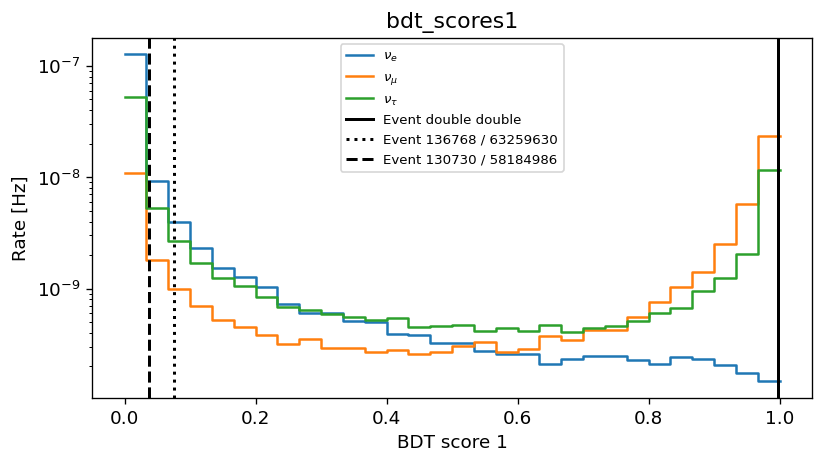

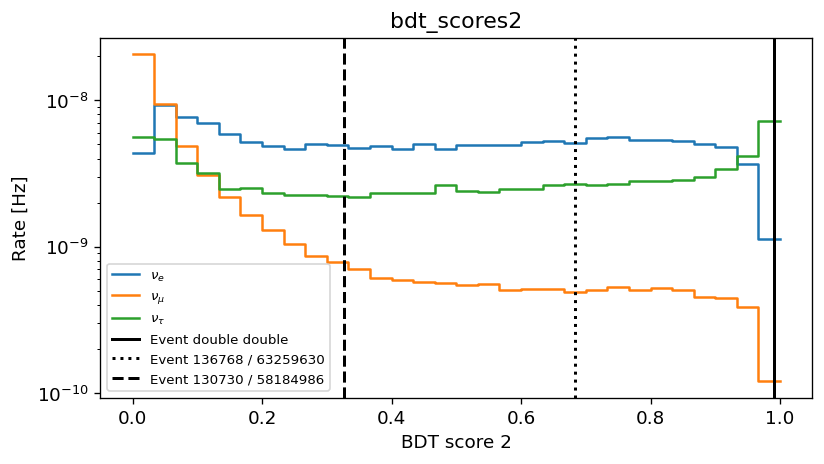

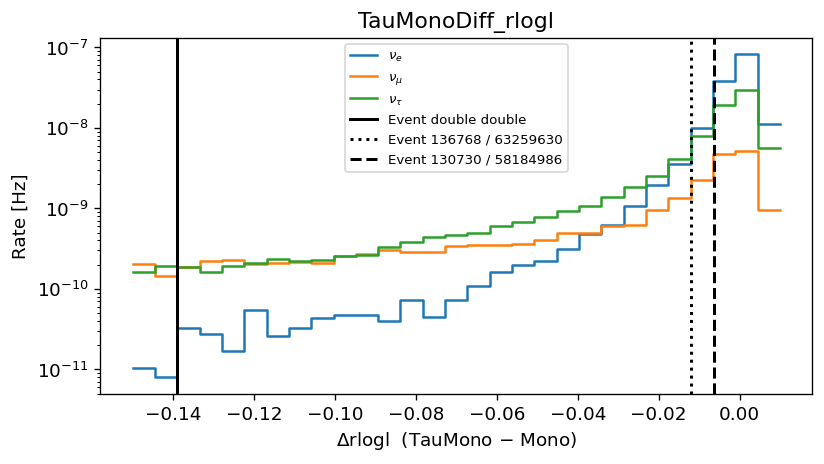

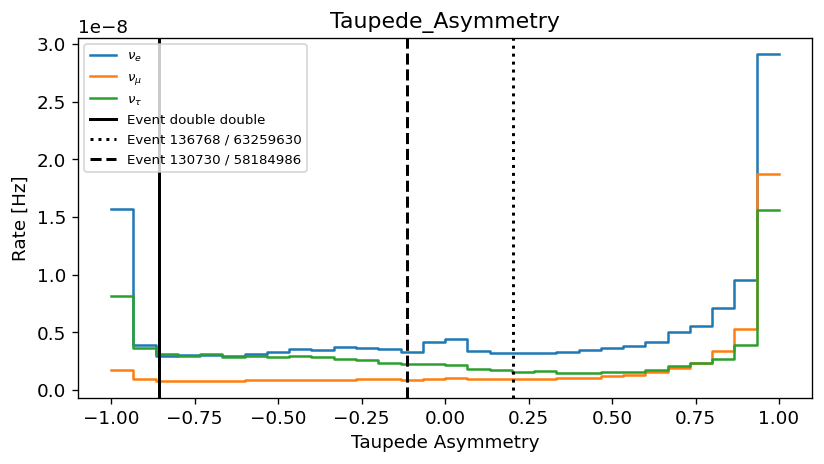

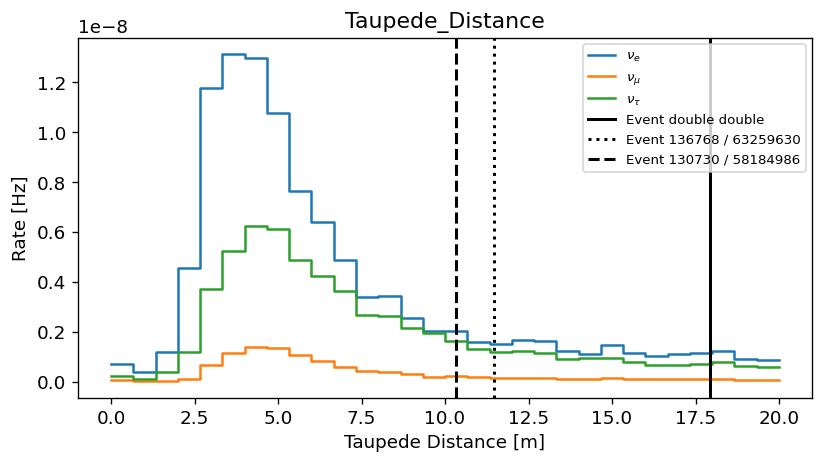

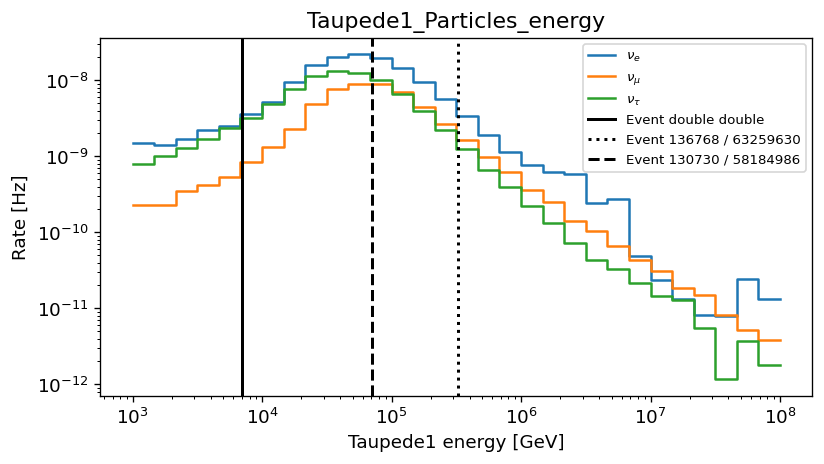

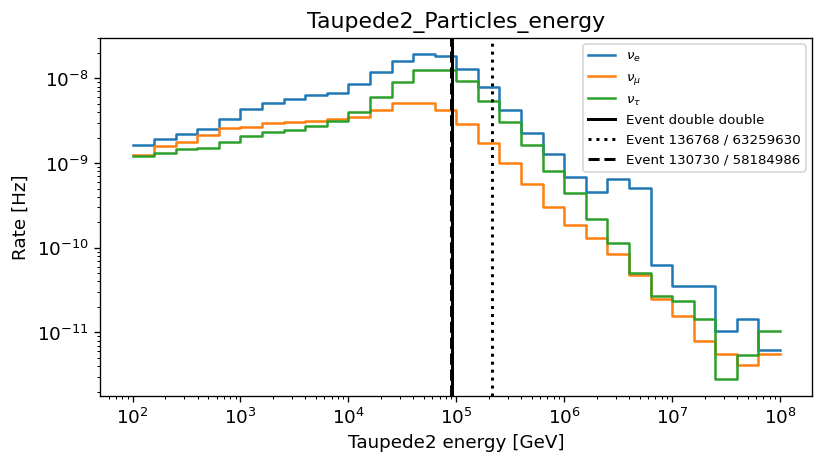

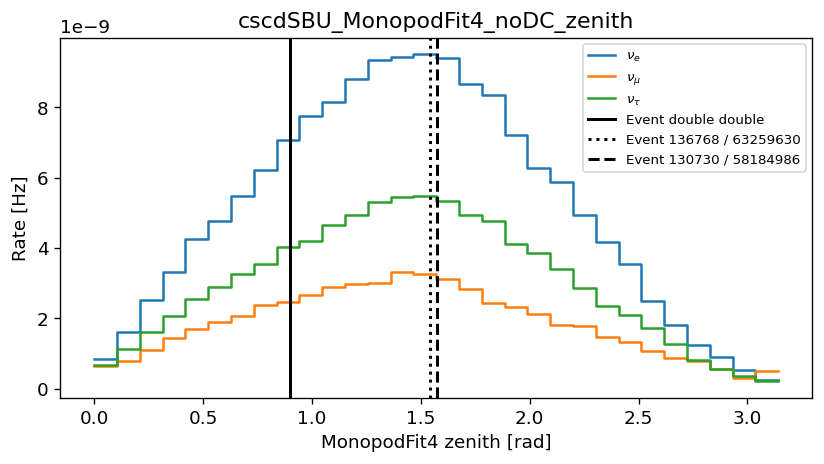

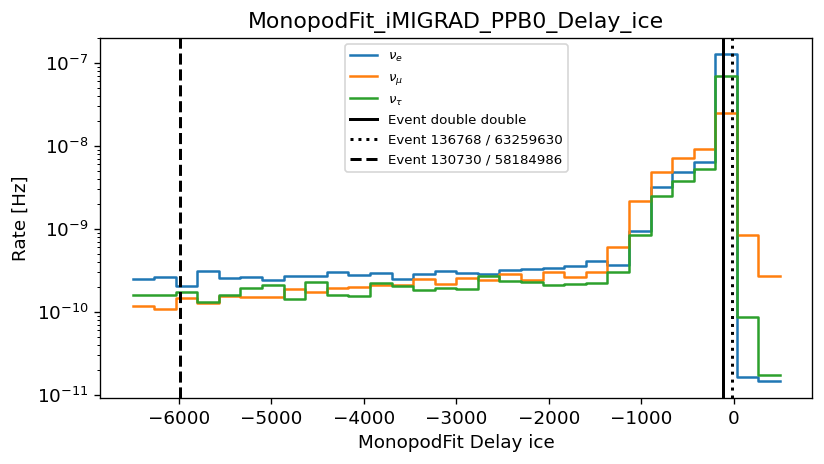

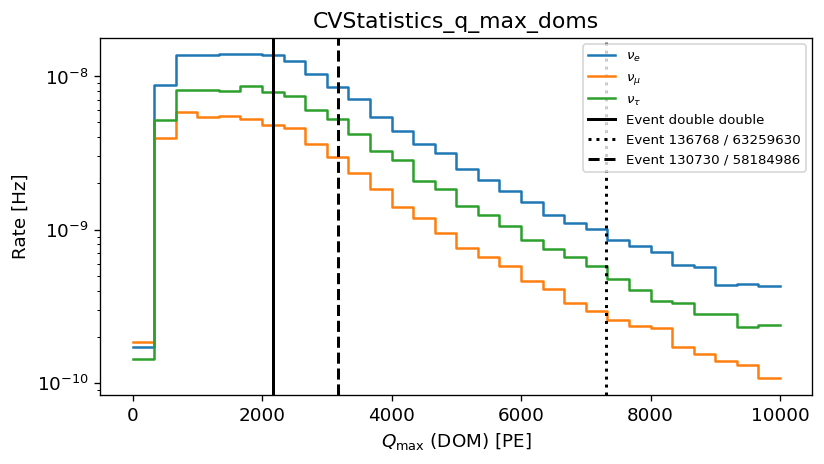

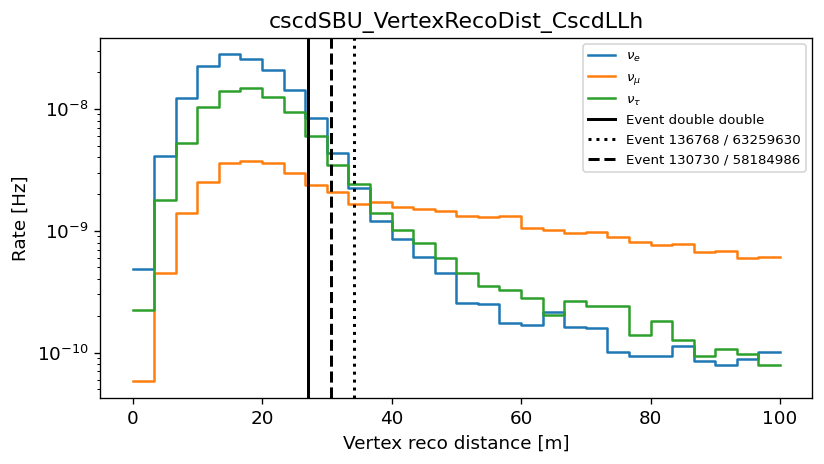

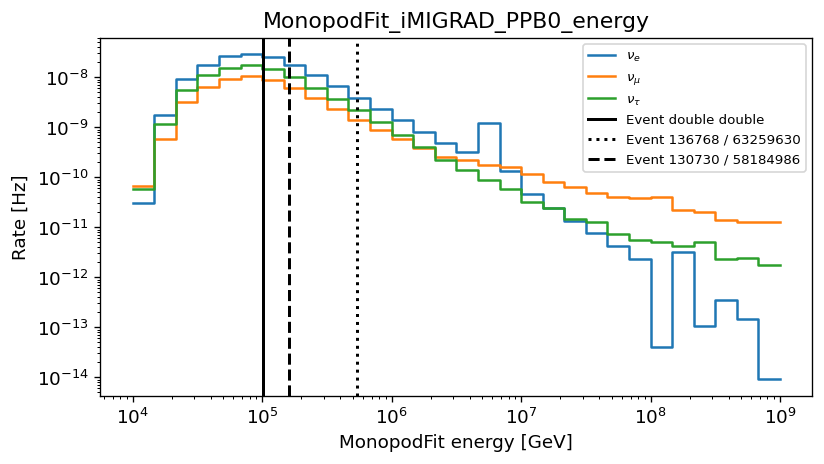

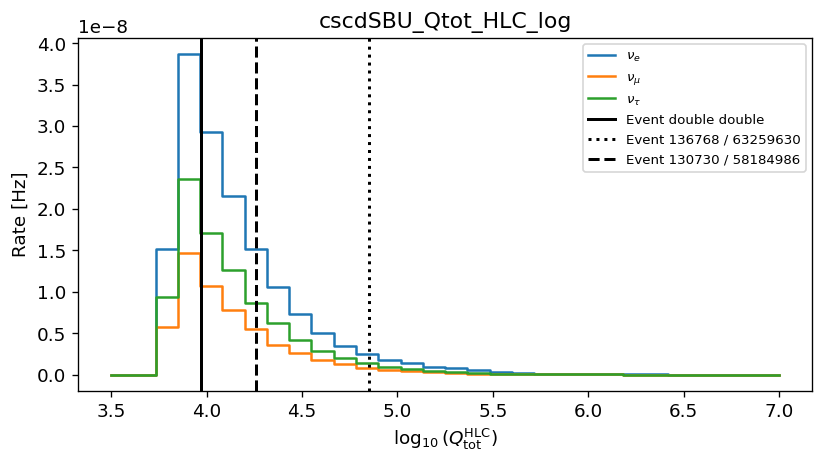

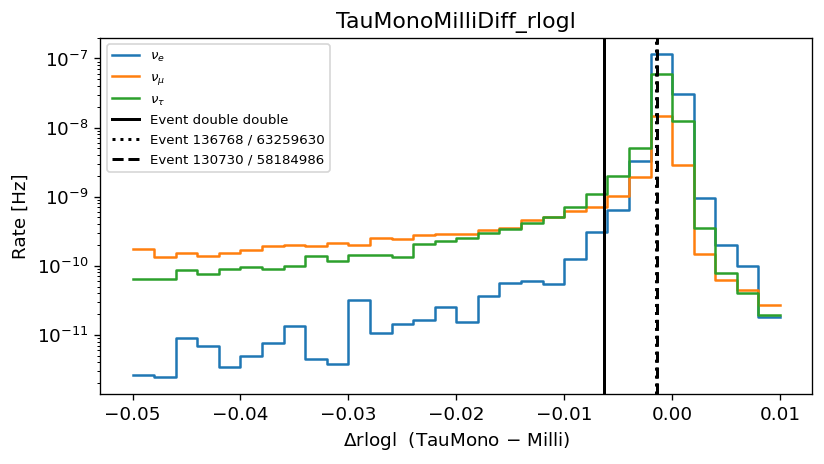

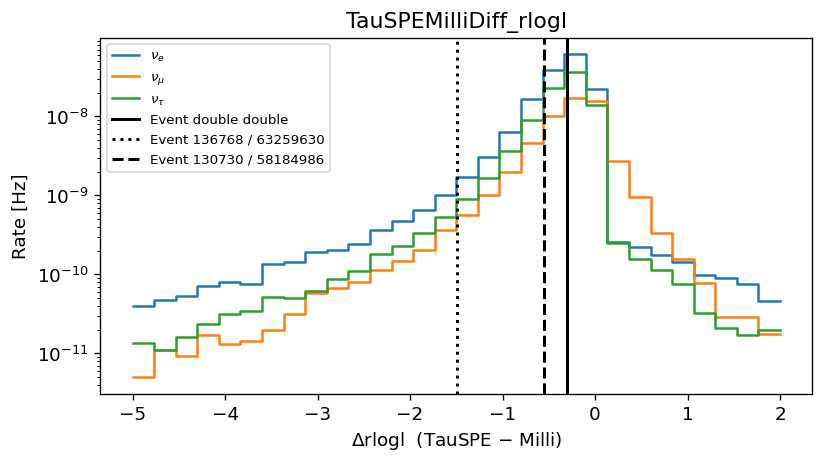

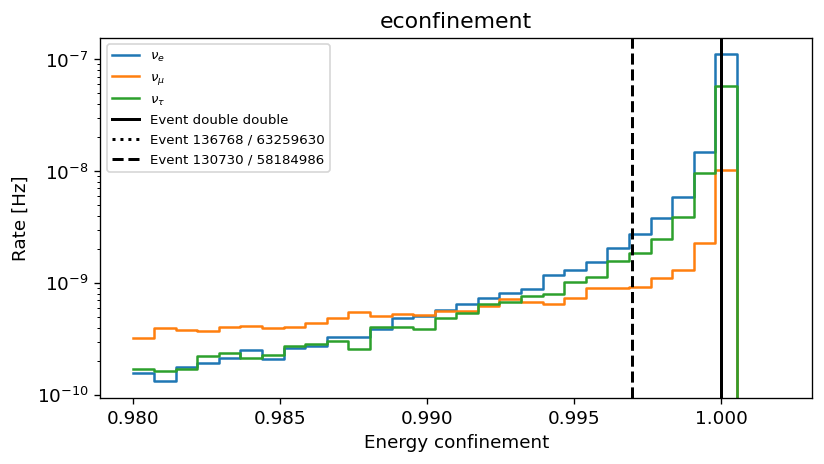

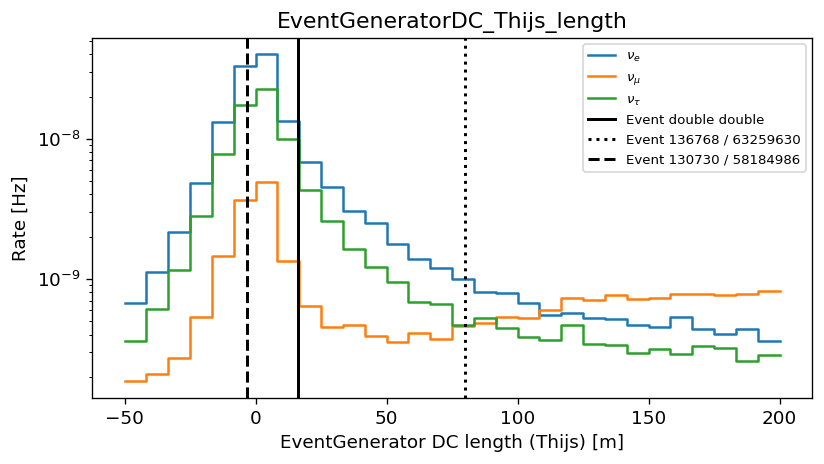

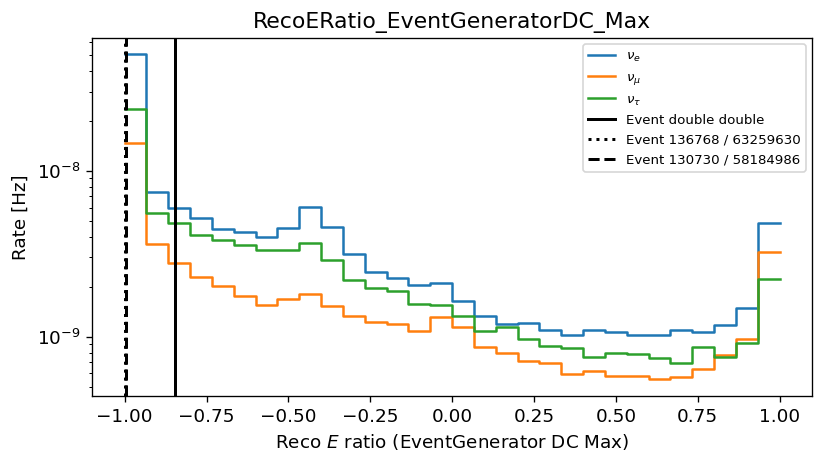

In [63]:
for variable, xlabel, bins, log_x, log_y in VARIABLE_SPECS:
    fig = plot_variable(variable, xlabel, bins, log_x=log_x, log_y=log_y)
    fig.savefig(os.path.join(SAVE_PATH, f'{variable}.png'), bbox_inches='tight')
    plt.show()

## 7. Summary table of data event values

In [64]:
rows = [
    {
        'variable':     variable,
        'xlabel':       xlabel,
        'event_136768': get_event_value(136768, 63259630, variable),
        'event_130730': get_event_value(130730, 58184986, variable),
    }
    for variable, xlabel, _, _, _ in VARIABLE_SPECS
]

df_summary = pd.DataFrame(rows).set_index('variable')
df_summary.style \
    .set_caption('Data event values for the two FinalTopology double-cascade events') \
    .format({'event_136768': '{:.4g}', 'event_130730': '{:.4g}'})

,xlabel,event_136768,event_130730
variable,,,
bdt_scores1,BDT score 1,0.07492,0.0369
bdt_scores2,BDT score 2,0.6835,0.327
TauMonoDiff_rlogl,$\Delta$rlogl (TauMono $-$ Mono),-0.01192,-0.006384
Taupede_Asymmetry,Taupede Asymmetry,0.2038,-0.1137
Taupede_Distance,Taupede Distance [m],11.46,10.34
Taupede1_Particles_energy,Taupede1 energy [GeV],3.25e+05,7.047e+04
Taupede2_Particles_energy,Taupede2 energy [GeV],2.15e+05,8.856e+04
cscdSBU_MonopodFit4_noDC_zenith,MonopodFit4 zenith [rad],1.544,1.574
MonopodFit_iMIGRAD_PPB0_Delay_ice,MonopodFit Delay ice,-15.07,-5982
